--- Domain 40.0x27.0 | Ell=4.0 ---
90.0% Variance: Rank 41
95.0% Variance: Rank 62
99.0% Variance: Rank 143


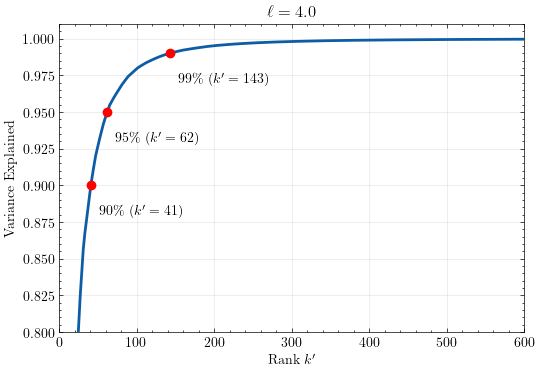

Variance explained by rank 32: 86.17%
Variance explained by rank 64: 95.31%
Variance explained by rank 128: 98.74%
Variance explained by rank 41: 90.08%
Variance explained by rank 62: 95.01%
Variance explained by rank 143: 99.01%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_func
import scienceplots

plt.style.use('science')

# --- Math Functions (Rectangular) ---
def matern_spectral_density_2d(omega_sq, nu, ell, rho):
    dim = 2
    # Scaling constant
    coeff = (rho**2) * (4 * np.pi)**(dim / 2) * gamma_func(nu + dim / 2) / gamma_func(nu)
    coeff *= (2 * nu / ell**2)**nu
    base = (2 * nu / ell**2) + omega_sq
    return coeff * (base ** -(nu + dim / 2))

def analyze_variance_capture_rect(params, Lx, Ly, max_wavenumber=60):
    """
    Analyzes variance capture for a Rectangular Domain (Lx, Ly).
    """
    rho, ell = params[2], params[3]
    nu = 2.5
    
    # 1. Generate integer wavenumbers
    k_range = np.arange(-max_wavenumber, max_wavenumber + 1)
    kx, ky = np.meshgrid(k_range, k_range)
    kx, ky = kx.flatten(), ky.flatten()
    
    # 2. Compute Eigenvalues (Rectangular Laplacian)
    # lambda = (2*pi*kx/Lx)^2 + (2*pi*ky/Ly)^2
    freq_x = (2 * np.pi * kx) / Lx
    freq_y = (2 * np.pi * ky) / Ly
    eigenvalues = freq_x**2 + freq_y**2
    
    # 3. Compute Spectral Density
    densities = matern_spectral_density_2d(eigenvalues, nu, ell, rho)
    
    # 4. Sort Descending
    sorted_indices = np.argsort(densities)[::-1]
    sorted_densities = densities[sorted_indices]
    
    # 5. Cumulative Sum
    cumulative_variance = np.cumsum(sorted_densities)
    total_variance_pool = np.sum(sorted_densities)
    
    # Normalize
    percentages = cumulative_variance / total_variance_pool
    
    return percentages, total_variance_pool

# --- Configuration ---
# Current Sim Parameters
Lx = 40.0
Ly = 27.0

# HYPERPARAMETER GUESSES
# rho: Scale of model error.
# ell: Correlation length of model error.
rho_guess = 3.0 
ell_guess = 4.0 

# params = [unused, unused, rho, ell, rank, sigma_obs]
params_test = [0, 0, rho_guess, ell_guess, 0, 0] 

# --- Run Analysis ---
percentages, total_var = analyze_variance_capture_rect(params_test, Lx, Ly, max_wavenumber=60)

# --- Find Cutoffs ---
def find_rank(p): return np.argmax(percentages >= p) + 1

def get_variance_explained(rank, percentages):
    """
    Given a rank k', return the proportion of variance explained.
    rank: The number of modes to use (e.g., 50)
    percentages: The array returned by analyze_variance_capture_rect
    """
    # Ensure rank is within bounds
    if rank < 1: return 0.0
    if rank > len(percentages): return percentages[-1]
    
    # Ranks are 1-based, indices are 0-based
    return percentages[rank - 1]

r90 = find_rank(0.90)
r95 = find_rank(0.95)
r99 = find_rank(0.99)

print(f"--- Domain {Lx}x{Ly} | Ell={ell_guess} ---")
print(f"90.0% Variance: Rank {r90}")
print(f"95.0% Variance: Rank {r95}")
print(f"99.0% Variance: Rank {r99}")

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 4))
ranks = np.arange(1, len(percentages) + 1)

ax.plot(ranks, percentages, lw=2)
ax.scatter([r90, r95, r99], [0.90, 0.95, 0.99], c='red', zorder=5)
ax.annotate(rf"90\% ($k' ={r90}$)", (r90, 0.90), xytext=(r90+10, 0.88))
ax.annotate(rf"95\% ($k' ={r95}$)", (r95, 0.95), xytext=(r95+10, 0.93))
ax.annotate(rf"99\% ($k' ={r99}$)", (r99, 0.99), xytext=(r99+10, 0.97))

ax.set_xlim(0, 600)
ax.set_ylim(0.8, 1.01)
ax.set_xlabel(r"Rank $k'$")
ax.set_ylabel("Variance Explained")
ax.set_title(f"$\ell={ell_guess}$")
ax.grid(True, alpha=0.3)
# save_path = "results/final/diffusionrank.pdf"
# plt.savefig(save_path, dpi=300)
plt.show()

my_rank = 32
var_expl = get_variance_explained(my_rank, percentages)
print(f"Variance explained by rank {my_rank}: {var_expl:.2%}")
my_rank = 64
var_expl = get_variance_explained(my_rank, percentages)
print(f"Variance explained by rank {my_rank}: {var_expl:.2%}")
my_rank = 128
var_expl = get_variance_explained(my_rank, percentages)
print(f"Variance explained by rank {my_rank}: {var_expl:.2%}")

my_rank = r90
var_expl = get_variance_explained(my_rank, percentages)
print(f"Variance explained by rank {my_rank}: {var_expl:.2%}")
my_rank = r95
var_expl = get_variance_explained(my_rank, percentages)
print(f"Variance explained by rank {my_rank}: {var_expl:.2%}")
my_rank = r99
var_expl = get_variance_explained(my_rank, percentages)
print(f"Variance explained by rank {my_rank}: {var_expl:.2%}")